In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from src.helper import get_split_data

In [2]:
df_matches = pd.read_csv('../../data/preprocessed/imputed_data.csv')
df_matches.sort_values(by=["season", "stage", "date"], inplace=True)

feature_cols = [col for col in df_matches.columns if col not in
                    ["match_api_id", "result_match", "season", "stage", "date", "home_team", "away_team"]]

X = df_matches[feature_cols]
y = df_matches['result_match']

Predicted classes: [0 1]
Accuracy: 0.618
F1 Score: 0.568
ROC AUC: 0.613

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.68      0.66      1618
           1       0.59      0.55      0.57      1357

    accuracy                           0.62      2975
   macro avg       0.61      0.61      0.61      2975
weighted avg       0.62      0.62      0.62      2975



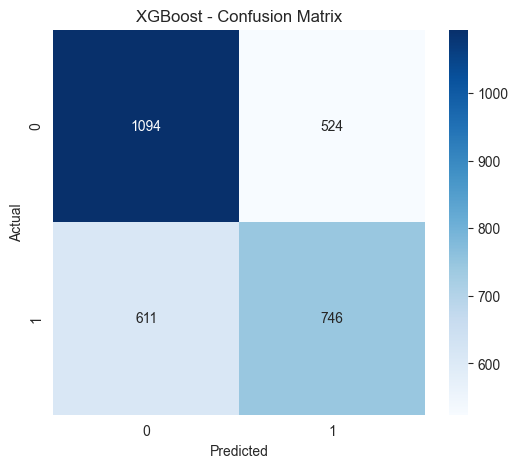

In [3]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

xgb = XGBClassifier(booster='gbtree',
                    objective='binary:logistic',
                    n_estimators=300,
                    max_depth=6)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_splits = cv.split(X, y)

y_pred_cv = cross_val_predict(xgb, X, y, cv=cv_splits, method='predict')

print("Predicted classes:", np.unique(y_pred_cv))

accuracy = accuracy_score(y, y_pred_cv)
f1 = f1_score(y, y_pred_cv)
roc_auc = roc_auc_score(y, y_pred_cv)
cm = confusion_matrix(y, y_pred_cv)

print(f'Accuracy: {accuracy:.3f}')
print(f'F1 Score: {f1:.3f}')
print(f'ROC AUC: {roc_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y, y_pred_cv))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost - Confusion Matrix')
plt.show()
